### Investigate the element predictions of the legnet model (WTC11)
- get the distribution of element predictions
```bash
python /home/kisa11/work/projects/NGN2_design/human_legnet/fasta_predict.py --config /home/kisa11/work/projects/NGN2_design/2025_IGVF_design_WTC11_neural_progenitors/model/final_dump/models/WTC11/md_shift_reverse_noavg_noch/config_legnet_example.json --model /home/kisa11/work/projects/NGN2_design/2025_IGVF_design_WTC11_neural_progenitors/model/final_dump/models/WTC11/md_shift_reverse_noavg_noch/best_model_test1_val2.ckpt --fasta /home/kisa11/work/projects/NGN2_design/2025_IGVF_design_WTC11_neural_progenitors/resources/cCREs_all_human_SCREEN/cCREs_all_human_SCREEN_230bp_upper.fa --out_path /home/kisa11/work/projects/NGN2_design/2025_IGVF_design_WTC11_neural_progenitors/data/cCREs_all_human_SCREEN_legnet_WTC11_230bp_pred.tsv --device 0 --batch_size 1
```
### NOTE about the updated second version:
- The second version failed as well because many sequences used for the predictions are within regions which contain TSS or CTCF sites. The updated second version will filter these regions out in the beginning - before the regions are chosen for the variant predictions.

In [35]:
from importlib import reload
import os
import pandas as pd
import yaml
import sys
import matplotlib.pyplot as plt

sys.path.append('../')
import helpful_functions as hf
reload(hf)

# config
config_path = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_2025_design_WTC11/config/2025_IGVF_design_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

write_output = False

element_prediction_tsv = config["files"]["common_WTC11_H9_H1_SCREEN_cCREs_centered_230bp_predicted"]

In [5]:
element_prediction_df = pd.read_csv(element_prediction_tsv, sep="\t", header=None, names=["header", "prediction"])
element_prediction_df

,header,prediction
0,EH38E1226372::chr3:134485990-134486190,1.138123
1,EH38E1310345::chr1:1000138-1000338,0.316687
2,EH38E1311174::chr1:1778875-1779075,-1.213996
3,EH38E1311175::chr1:1779302-1779502,-1.114222
4,EH38E1311178::chr1:1780324-1780524,-1.221150
...,...,...
28244,EH38E4530218::chrX:134237051-134237251,-1.018489
28245,EH38E4532545::chrX:149939816-149940016,-0.407178
28246,EH38E4533413::chrX:153972137-153972337,1.258971
28247,EH38E4533533::chrX:154547203-154547403,1.757106


### Second version: WTC11, H9, H1 open chromatin

In [6]:
# print min max mean and median
print(f"Min: {element_prediction_df['prediction'].min()}, Max: {element_prediction_df['prediction'].max()}, Mean: {element_prediction_df['prediction'].mean()}, Median: {element_prediction_df['prediction'].median()}")

# 90th percentile
print(f"90th percentile: {element_prediction_df['prediction'].quantile(0.9)}")

# how many are above 0.5
print(f"Number of elements above 0.5: {len(element_prediction_df[element_prediction_df['prediction'] > 0.5])} ({round(len(element_prediction_df[element_prediction_df['prediction'] > 0.5]) / len(element_prediction_df) * 100,2)}%)")

# Min: -2.826, Max: 5.75, Mean: -1.028194386138242, Median: -1.158
# 90th percentile: -0.5347
# Number of elements above 0.5: 108287 (2.8%)

# Min: -2.236422222222222, Max: 2.897944444444444, Mean: -0.03639157677437549, Median: -0.2684814444444444
# 90th percentile: 1.6023722222222223
# Number of elements above 0.5: 9956 (35.24%)

Min: -2.236422222222222, Max: 2.897944444444444, Mean: -0.03639157677437549, Median: -0.2684814444444444
90th percentile: 1.6023722222222223
Number of elements above 0.5: 9956 (35.24%)


In [7]:
element_prediction_df.header.nunique() # 28249
element_prediction_df.shape[0] # 28249

28249

In [8]:
element_prediction_df

,header,prediction
0,EH38E1226372::chr3:134485990-134486190,1.138123
1,EH38E1310345::chr1:1000138-1000338,0.316687
2,EH38E1311174::chr1:1778875-1779075,-1.213996
3,EH38E1311175::chr1:1779302-1779502,-1.114222
4,EH38E1311178::chr1:1780324-1780524,-1.221150
...,...,...
28244,EH38E4530218::chrX:134237051-134237251,-1.018489
28245,EH38E4532545::chrX:149939816-149940016,-0.407178
28246,EH38E4533413::chrX:153972137-153972337,1.258971
28247,EH38E4533533::chrX:154547203-154547403,1.757106


In [9]:
element_prediction_df

,header,prediction
0,EH38E1226372::chr3:134485990-134486190,1.138123
1,EH38E1310345::chr1:1000138-1000338,0.316687
2,EH38E1311174::chr1:1778875-1779075,-1.213996
3,EH38E1311175::chr1:1779302-1779502,-1.114222
4,EH38E1311178::chr1:1780324-1780524,-1.221150
...,...,...
28244,EH38E4530218::chrX:134237051-134237251,-1.018489
28245,EH38E4532545::chrX:149939816-149940016,-0.407178
28246,EH38E4533413::chrX:153972137-153972337,1.258971
28247,EH38E4533533::chrX:154547203-154547403,1.757106


In [10]:
# investigate the top 5000 predictions:
element_prediction_df_sorted = element_prediction_df.sort_values(by=["prediction"], ascending=False)
element_prediction_df_sorted_top5000 = element_prediction_df_sorted.head(5000)
element_prediction_df_sorted_top5000['prediction'].describe()

# count    5000.000000
# mean        1.688419
# std         0.255655
# min         1.311540
# 25%         1.476328
# 50%         1.653833
# 75%         1.861835
# max         2.897944

count    5000.000000
mean        1.688419
std         0.255655
min         1.311540
25%         1.476328
50%         1.653833
75%         1.861835
max         2.897944
Name: prediction, dtype: float64

In [11]:
# load the cCREs fasta file and get the sequence information
cCREs_fasta_name = config["files"]["common_WTC11_H9_H1_SCREEN_cCREs_centered_prediction_ready_fa"]
WTC11_H9_H1_open_screen_fasta_df = hf.fasta_to_dataframe(cCREs_fasta_name)

In [12]:
print("Shape:", WTC11_H9_H1_open_screen_fasta_df.shape[0]) #3874560 expected
print("Unique sequences:", WTC11_H9_H1_open_screen_fasta_df.sequence.nunique()) #3866537 expected
print("Unique headers:", WTC11_H9_H1_open_screen_fasta_df.header.nunique()) #3866537 expected
WTC11_H9_H1_open_screen_fasta_df.head()

Shape: 28249
Unique sequences: 28249
Unique headers: 28249


,header,sequence
0,EH38E1226372::chr3:134485990-134486190,AGGACCGGATCAACTGCCCCCCCCCCCTCCCCCGCATCACGTGTCT...
1,EH38E1310345::chr1:1000138-1000338,AGGACCGGATCAACTCGGGGTGTGTGAACCCGGCTCCGCATTCTTT...
2,EH38E1311174::chr1:1778875-1779075,AGGACCGGATCAACTTGGGCCGGCTCAGGGGAGTGCAGGTGCCCCG...
3,EH38E1311175::chr1:1779302-1779502,AGGACCGGATCAACTGAACTGCGGGTCCCACCCAGCCCGCACTTGC...
4,EH38E1311178::chr1:1780324-1780524,AGGACCGGATCAACTAGTGGAGGCAGTCAACTGCTTCTGCAGAGGC...


In [13]:
WTC11_H9_H1_open_screen_fasta_df['sequence'].str.len().value_counts()

sequence
230    28249
Name: count, dtype: int64

In [14]:
# join the prediction to the fasta df
WTC11_H9_H1_open_screen_200bp_pred_df = WTC11_H9_H1_open_screen_fasta_df.merge(element_prediction_df, on="header", how="inner")

In [15]:
WTC11_H9_H1_open_screen_200bp_pred_df

,header,sequence,prediction
0,EH38E1226372::chr3:134485990-134486190,AGGACCGGATCAACTGCCCCCCCCCCCTCCCCCGCATCACGTGTCT...,1.138123
1,EH38E1310345::chr1:1000138-1000338,AGGACCGGATCAACTCGGGGTGTGTGAACCCGGCTCCGCATTCTTT...,0.316687
2,EH38E1311174::chr1:1778875-1779075,AGGACCGGATCAACTTGGGCCGGCTCAGGGGAGTGCAGGTGCCCCG...,-1.213996
3,EH38E1311175::chr1:1779302-1779502,AGGACCGGATCAACTGAACTGCGGGTCCCACCCAGCCCGCACTTGC...,-1.114222
4,EH38E1311178::chr1:1780324-1780524,AGGACCGGATCAACTAGTGGAGGCAGTCAACTGCTTCTGCAGAGGC...,-1.221150
...,...,...,...
28244,EH38E4530218::chrX:134237051-134237251,AGGACCGGATCAACTGCCGCGGTACCCGCTTCACCGGGCATGCTCA...,-1.018489
28245,EH38E4532545::chrX:149939816-149940016,AGGACCGGATCAACTGGAGCAGGCCGGGGCAGTGGGCAATTGAGCG...,-0.407178
28246,EH38E4533413::chrX:153972137-153972337,AGGACCGGATCAACTGCGTCAATAGCGACTTTCAGCACAAAACAAA...,1.258971
28247,EH38E4533533::chrX:154547203-154547403,AGGACCGGATCAACTAGGGCTCCACTTCCGCCGGCAGCGTGGCCAC...,1.757106


In [16]:
print("Shape:", WTC11_H9_H1_open_screen_200bp_pred_df.shape[0]) # 3866537 expected
print("Unique sequences:", WTC11_H9_H1_open_screen_200bp_pred_df.sequence.nunique()) # 3866537 expected

Shape: 28249
Unique sequences: 28249


#### Use the MPRAoligo design results from all regions of WTC11, H9 and H1


In [2]:
design_fasta_path = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_2025_design_WTC11/MPRAOligoDesign/MPRAOligoDesign_test_all_WTC11_H9_H1_combined_open_regions_200bp/final_design/design.fa.gz"
mpraoligo_design_fasta_df = hf.fasta_to_dataframe(design_fasta_path)

In [17]:
mpraoligo_design_fasta_df["SCREEN_ID"] = mpraoligo_design_fasta_df["header"].str.split(":").str[1]
mpraoligo_design_fasta_df["SCREEN_ID"] = mpraoligo_design_fasta_df["SCREEN_ID"].str.split("(").str[0]
mpraoligo_design_fasta_df

,header,sequence,SCREEN_ID
0,all_combined_regions_2025_IGVF_design:EH38E131...,AGGACCGGATCAACTTGGGCCGGCTCAGGGGAGTGCAGGTGCCCCG...,EH38E1311174
1,all_combined_regions_2025_IGVF_design:EH38E131...,AGGACCGGATCAACTGAACTGCGGGTCCCACCCAGCCCGCACTTGC...,EH38E1311175
2,all_combined_regions_2025_IGVF_design:EH38E131...,AGGACCGGATCAACTCAGGGTGGGTTCTGAGCTTGGTGACCCGCTC...,EH38E1311688
3,all_combined_regions_2025_IGVF_design:EH38E131...,AGGACCGGATCAACTTCGCTTCATCCCTTCCCCCATTTCCTTCCTG...,EH38E1311740
4,all_combined_regions_2025_IGVF_design:EH38E131...,AGGACCGGATCAACTCACTAGCAGCACTGTGGAACCTAAGACCGGC...,EH38E1313036
...,...,...,...
11343,all_combined_regions_2025_IGVF_design:EH38E452...,AGGACCGGATCAACTTCACCTGGGAAGCACAAGGGGTCGGGGTATT...,EH38E4523792
11344,all_combined_regions_2025_IGVF_design:EH38E452...,AGGACCGGATCAACTTTTCCCCTACTCCTCATCCCCTCGCAACTTC...,EH38E4525683
11345,all_combined_regions_2025_IGVF_design:EH38E452...,AGGACCGGATCAACTGGGCGCGAGTAGCTGCCGTAATAGACTGACG...,EH38E4528033
11346,all_combined_regions_2025_IGVF_design:EH38E453...,AGGACCGGATCAACTGGAGCAGGCCGGGGCAGTGGGCAATTGAGCG...,EH38E4532545


In [18]:
element_prediction_df["SCREEN_ID"] = element_prediction_df["header"].str.split("::").str[0]
element_prediction_df

,header,prediction,SCREEN_ID
0,EH38E1226372::chr3:134485990-134486190,1.138123,EH38E1226372
1,EH38E1310345::chr1:1000138-1000338,0.316687,EH38E1310345
2,EH38E1311174::chr1:1778875-1779075,-1.213996,EH38E1311174
3,EH38E1311175::chr1:1779302-1779502,-1.114222,EH38E1311175
4,EH38E1311178::chr1:1780324-1780524,-1.221150,EH38E1311178
...,...,...,...
28244,EH38E4530218::chrX:134237051-134237251,-1.018489,EH38E4530218
28245,EH38E4532545::chrX:149939816-149940016,-0.407178,EH38E4532545
28246,EH38E4533413::chrX:153972137-153972337,1.258971,EH38E4533413
28247,EH38E4533533::chrX:154547203-154547403,1.757106,EH38E4533533


In [19]:
WTC11_H9_H1_open_screen_200bp_pred_df = mpraoligo_design_fasta_df[['SCREEN_ID', 'sequence']].merge(element_prediction_df, on="SCREEN_ID", how="inner")

In [20]:
WTC11_H9_H1_open_screen_200bp_pred_df_sorted = WTC11_H9_H1_open_screen_200bp_pred_df.sort_values(by=["prediction"], ascending=False)

In [21]:
WTC11_H9_H1_open_screen_200bp_pred_df_top5000 = WTC11_H9_H1_open_screen_200bp_pred_df_sorted.head(5000).copy()

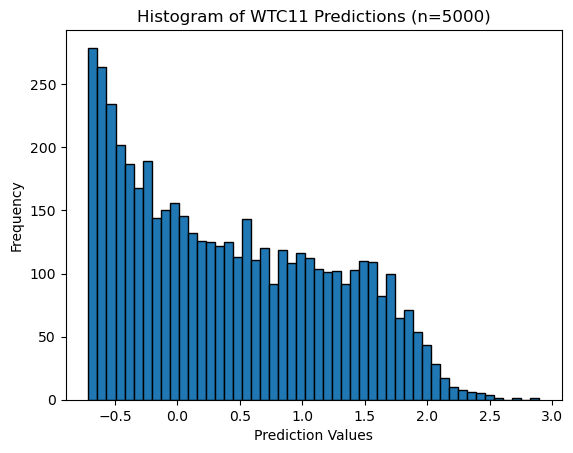

In [22]:
plt.hist(WTC11_H9_H1_open_screen_200bp_pred_df_top5000['prediction'], bins=50, edgecolor='black')
plt.title(f'Histogram of WTC11 Predictions (n={WTC11_H9_H1_open_screen_200bp_pred_df_top5000.shape[0]})')
plt.xlabel('Prediction Values')
plt.ylabel('Frequency')
plt.show()

In [23]:
WTC11_H9_H1_open_screen_200bp_pred_df_top5000['prediction'].describe()
# count    11348.000000
# mean        -0.473809
# std          0.976580
# min         -2.236422
# 25%         -1.167427
# 50%         -0.835733
# 75%          0.103959
# max          2.897944

# count    5000.000000
# mean        0.413821
# std         0.809493
# min        -0.712270
# 25%        -0.314069
# 50%         0.296994
# 75%         1.069951
# max         2.897944

count    5000.000000
mean        0.413821
std         0.809493
min        -0.712270
25%        -0.314069
50%         0.296994
75%         1.069951
max         2.897944
Name: prediction, dtype: float64

In [24]:
WTC11_H9_H1_open_screen_200bp_pred_df_top5000

,SCREEN_ID,sequence,header,prediction
1305,EH38E1883194,AGGACCGGATCAACTGAGGAAGGGGGAGGGGAGGTGGGGAAGGGGA...,EH38E1883194::chr17:72151065-72151265,2.897944
389,EH38E1475016,AGGACCGGATCAACTCACCCCCAGCCCCATTTGCTTAGTGTTGATG...,EH38E1475016::chr10:69329851-69330051,2.695478
9841,EH38E3885765,AGGACCGGATCAACTAGTTCTATATTGCTCTCATTTCCTTTTTCTC...,EH38E3885765::chr9:72680621-72680821,2.565722
7219,EH38E3394420,AGGACCGGATCAACTCACCGCCTCCGCCACTCCCGCGCCCGCCCCT...,EH38E3394420::chr2:202033616-202033816,2.521944
763,EH38E1627895,AGGACCGGATCAACTACTTCCGCGGTGAAGTGCAGGAGGTTTTAGA...,EH38E1627895::chr12:80684207-80684407,2.511533
...,...,...,...,...
2183,EH38E2284047,AGGACCGGATCAACTTGAAAATGGCCTGTTCCTGCCTTAACTGATG...,EH38E2284047::chr4:16918832-16919032,-0.711138
9675,EH38E3849179,AGGACCGGATCAACTCTCCCCCCGCGCCCGCCGACCCGCCAGCCCT...,EH38E3849179::chr8:102412136-102412336,-0.711163
10193,EH38E3948177,AGGACCGGATCAACTACTGCCGAGCGGGAGGAGGCCGGGGGCCGGG...,EH38E3948177::chrX:151177848-151178048,-0.711322
7234,EH38E3396737,AGGACCGGATCAACTGGTAGTGCTGCTCGTACAGGTAGCAGGCCAC...,EH38E3396737::chr2:207767316-207767516,-0.711768


In [25]:
# sanity check the header (correctly defined regions in hg38)
WTC11_H9_H1_open_screen_200bp_pred_df_top5000['sequence_without_adapter'] = WTC11_H9_H1_open_screen_200bp_pred_df_top5000['sequence'].apply(lambda seq: seq[15:-15])


In [ ]:
# store as fasta file
output_path_element_metadata = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_2025_design_WTC11/results/combined_WTC11_H9_H1_element_results/filtered_combined_WTC11_H9_H1_element_results/top5000_WTC11_H9_H1_open_screen_200bp_pred_metadata.tsv"
output_path_element_metadata = config['files']['prefiltered_common_WTC11_H9_H1_SCREEN_cCREs_centered_5000_most_active_table']
output_path_element_fasta = config['files']['prefiltered_common_WTC11_H9_H1_SCREEN_cCREs_centered_5000_most_active_fasta']


# metadata:
if write_output:
    WTC11_H9_H1_open_screen_200bp_pred_df_top5000.to_csv(output_path_element_metadata, sep="\t", index=False)

# fasta:
if write_output:
    hf.write_fasta(WTC11_H9_H1_open_screen_200bp_pred_df_top5000, output_path_element_fasta)

In [37]:
# write the bed file of the regions

# regex for the chromosome, start and end
pattern = r"::(chr[\w\d]+):(\d+)-(\d+)"

# Extract chromosome, start, and end coordinates
WTC11_H9_H1_open_screen_200bp_pred_df_top5000[['chr', 'start', 'end']] = WTC11_H9_H1_open_screen_200bp_pred_df_top5000['header'].str.extract(pattern)

WTC11_H9_H1_open_screen_200bp_pred_df_top5000['score'] = 0
WTC11_H9_H1_open_screen_200bp_pred_df_top5000['strand'] = "+"
WTC11_H9_H1_open_screen_200bp_pred_df_top5000[['chr', 'start', 'end', 'header', 'score', 'strand']].to_csv(config['files']['prefiltered_common_WTC11_H9_H1_SCREEN_cCREs_centered_5000_most_active_bed'], index=False, header=None, sep="\t")

In [ ]:
# use bedtools
# bedtools slop -b 35 -i /data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_2025_design_WTC11/results/combined_WTC11_H9_H1_element_results/filtered_combined_WTC11_H9_H1_element_results/top5000_WTC11_H9_H1_open_screen_200bp.bed -g /data/cephfs-1/work/projects/cubit/18.12/static_data/reference/hg38/ucsc/hg38.fa.genome > /data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_2025_design_WTC11/results/combined_WTC11_H9_H1_element_results/filtered_combined_WTC11_H9_H1_element_results/top5000_WTC11_H9_H1_open_screen_270b.bed
# to test the extended version of the regions => use this result to get the correctly defined
# bedtools slop -b 35 -i <( zcat common_WTC11_H9_H1_SCREEN_ID_no_low-DNase_no_chromatinAccessibility_centered_200b.bed.gz ) -g /data/cephfs-1/work/projects/cubit/18.12/static_data/reference/hg38/ucsc/hg38.fa.genome > /data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_2025_design_WTC11/results/combined_WTC11_H9_H1_element_results/extended_common_WTC11_H9_H1_SCREEN_ID_no_low-DNase_no_chromatinAccessibility_centered_270b.bed


### Visualize the element predictions of the legnet model (WTC11)

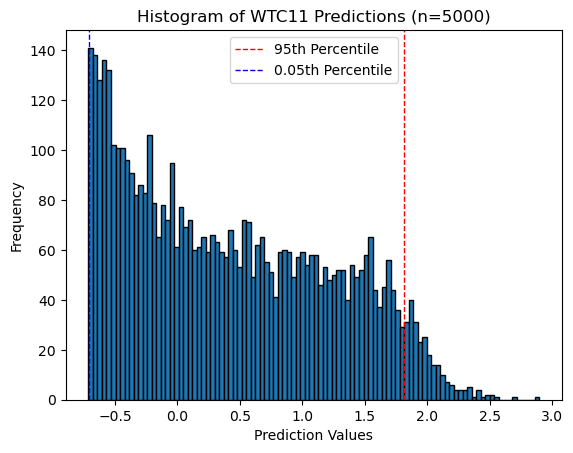

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the 95th percentile and 0.05 percentile
percentile_95 = np.percentile(WTC11_H9_H1_open_screen_200bp_pred_df['prediction'], 95)
percentile_005 = np.percentile(WTC11_H9_H1_open_screen_200bp_pred_df['prediction'], 0.05)

# Calculate the number of sequences lower than the 5th percentile and higher than the 95th percentile
sequences_lower_than_5th = np.sum(WTC11_H9_H1_open_screen_200bp_pred_df['prediction'] < percentile_005)
sequences_higher_than_95th = np.sum(WTC11_H9_H1_open_screen_200bp_pred_df['prediction'] > percentile_95)
sequences_middle = WTC11_H9_H1_open_screen_200bp_pred_df.loc[(WTC11_H9_H1_open_screen_200bp_pred_df['prediction'] < percentile_95) & (WTC11_H9_H1_open_screen_200bp_pred_df['prediction'] > percentile_005)].shape[0]

# Plot the histogram of the predictions
plt.hist(WTC11_H9_H1_open_screen_200bp_pred_df['prediction'], bins=100, edgecolor='black')
plt.axvline(percentile_95, color='r', linestyle='dashed', linewidth=1, label='95th Percentile')
plt.axvline(percentile_005, color='b', linestyle='dashed', linewidth=1, label='0.05th Percentile')
plt.title(f'Histogram of WTC11 Predictions (n={WTC11_H9_H1_open_screen_200bp_pred_df.shape[0]})')
plt.xlabel('Prediction Values')
plt.ylabel('Frequency')
plt.legend()

# # Add text annotations for the number of sequences lower than the 5th percentile and higher than the 95th percentile
# plt.text(-3, 500000, f'# {sequences_lower_than_5th}', color='blue', fontsize=6)
# plt.text(0.7, 500000, f'# {sequences_higher_than_95th}', color='red', fontsize=6)
# plt.text(-1, 500000, f'# {sequences_middle}', color='black', fontsize=6)
plt.show()

### Collecting elements for ism variant prediction
0. Get table
1. Collect 5k highest

In [27]:
WTC11_H9_H1_open_screen_200bp_pred_df

,header,sequence,prediction
0,EH38E1226372::chr3:134485990-134486190,AGGACCGGATCAACTGCCCCCCCCCCCTCCCCCGCATCACGTGTCT...,1.138123
1,EH38E1310345::chr1:1000138-1000338,AGGACCGGATCAACTCGGGGTGTGTGAACCCGGCTCCGCATTCTTT...,0.316687
2,EH38E1311174::chr1:1778875-1779075,AGGACCGGATCAACTTGGGCCGGCTCAGGGGAGTGCAGGTGCCCCG...,-1.213996
3,EH38E1311175::chr1:1779302-1779502,AGGACCGGATCAACTGAACTGCGGGTCCCACCCAGCCCGCACTTGC...,-1.114222
4,EH38E1311178::chr1:1780324-1780524,AGGACCGGATCAACTAGTGGAGGCAGTCAACTGCTTCTGCAGAGGC...,-1.221150
...,...,...,...
28244,EH38E4530218::chrX:134237051-134237251,AGGACCGGATCAACTGCCGCGGTACCCGCTTCACCGGGCATGCTCA...,-1.018489
28245,EH38E4532545::chrX:149939816-149940016,AGGACCGGATCAACTGGAGCAGGCCGGGGCAGTGGGCAATTGAGCG...,-0.407178
28246,EH38E4533413::chrX:153972137-153972337,AGGACCGGATCAACTGCGTCAATAGCGACTTTCAGCACAAAACAAA...,1.258971
28247,EH38E4533533::chrX:154547203-154547403,AGGACCGGATCAACTAGGGCTCCACTTCCGCCGGCAGCGTGGCCAC...,1.757106


In [28]:
def get_chr(header):
    # EH38E1226372::chr3:134485990-134486190
    region_header = header.split("::")[1]
    return region_header.split(":")[0]

def get_start(header):
    region_header = header.split("::")[1]
    return int(region_header.split(":")[1].split("-")[0])

def get_end(header):
    region_header = header.split("::")[1]
    return int(region_header.split(":")[1].split("-")[1])

WTC11_H9_H1_open_screen_200bp_pred_df['chr'] = WTC11_H9_H1_open_screen_200bp_pred_df.header.apply(get_chr)
WTC11_H9_H1_open_screen_200bp_pred_df['start'] = WTC11_H9_H1_open_screen_200bp_pred_df.header.apply(get_start)
WTC11_H9_H1_open_screen_200bp_pred_df['end'] = WTC11_H9_H1_open_screen_200bp_pred_df.header.apply(get_end)

# rename prediction to seq_prediction
WTC11_H9_H1_open_screen_200bp_pred_df.rename(columns={"prediction": "seq_prediction"}, inplace=True)
WTC11_H9_H1_open_screen_200bp_pred_df['REF_ID'] = pd.NA

In [29]:
WTC11_H9_H1_open_screen_200bp_pred_df

,header,sequence,seq_prediction,chr,start,end,REF_ID
0,EH38E1226372::chr3:134485990-134486190,AGGACCGGATCAACTGCCCCCCCCCCCTCCCCCGCATCACGTGTCT...,1.138123,chr3,134485990,134486190,<NA>
1,EH38E1310345::chr1:1000138-1000338,AGGACCGGATCAACTCGGGGTGTGTGAACCCGGCTCCGCATTCTTT...,0.316687,chr1,1000138,1000338,<NA>
2,EH38E1311174::chr1:1778875-1779075,AGGACCGGATCAACTTGGGCCGGCTCAGGGGAGTGCAGGTGCCCCG...,-1.213996,chr1,1778875,1779075,<NA>
3,EH38E1311175::chr1:1779302-1779502,AGGACCGGATCAACTGAACTGCGGGTCCCACCCAGCCCGCACTTGC...,-1.114222,chr1,1779302,1779502,<NA>
4,EH38E1311178::chr1:1780324-1780524,AGGACCGGATCAACTAGTGGAGGCAGTCAACTGCTTCTGCAGAGGC...,-1.221150,chr1,1780324,1780524,<NA>
...,...,...,...,...,...,...,...
28244,EH38E4530218::chrX:134237051-134237251,AGGACCGGATCAACTGCCGCGGTACCCGCTTCACCGGGCATGCTCA...,-1.018489,chrX,134237051,134237251,<NA>
28245,EH38E4532545::chrX:149939816-149940016,AGGACCGGATCAACTGGAGCAGGCCGGGGCAGTGGGCAATTGAGCG...,-0.407178,chrX,149939816,149940016,<NA>
28246,EH38E4533413::chrX:153972137-153972337,AGGACCGGATCAACTGCGTCAATAGCGACTTTCAGCACAAAACAAA...,1.258971,chrX,153972137,153972337,<NA>
28247,EH38E4533533::chrX:154547203-154547403,AGGACCGGATCAACTAGGGCTCCACTTCCGCCGGCAGCGTGGCCAC...,1.757106,chrX,154547203,154547403,<NA>


(array([24., 14., 17., 24., 29., 20., 26., 23., 25., 23., 30., 22., 31.,
        23., 24., 26., 28., 18., 16., 27., 13., 27., 21., 27., 21., 26.,
        23., 20., 27., 19., 25., 24., 21., 31., 21., 20., 23., 24., 26.,
        33., 20., 27., 29., 34., 23., 22., 27., 35., 24., 22., 19., 27.,
        24., 20., 18., 17., 22., 24., 23., 22., 26., 19., 27., 20., 25.,
        27., 20., 32., 30., 23., 36., 26., 28., 14., 20., 30., 21., 24.,
        25., 27., 23., 23., 18., 27., 23., 18., 28., 14., 21., 22., 20.,
        22., 26., 13., 27., 16., 19., 19., 29., 16., 21., 27., 21., 11.,
        25., 15., 16., 21., 15., 16., 17., 25., 20., 20., 34., 33., 22.,
        21., 17., 28., 21., 18., 24., 23., 14., 13., 21., 27., 20., 26.,
        15., 24., 19., 10., 21., 26., 20., 20., 21., 14., 17., 14., 19.,
        15., 19., 11., 22., 21., 20., 18., 13., 22., 13., 20., 15., 22.,
        13., 13., 14., 11., 21., 25., 16., 16., 18., 16., 23., 20., 18.,
        20., 19., 20., 12., 16., 20., 15., 18., 14.

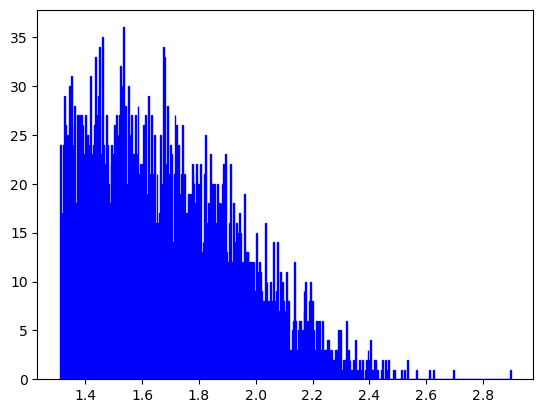

In [30]:
# high: get the 14000 highest scoring sequences
high_sequences = WTC11_H9_H1_open_screen_200bp_pred_df.sort_values(by="seq_prediction", ascending=False).head(5000)



# # visualize the prediction distribution of the low sequences
# plt.hist(low_sequences["seq_prediction"], bins=500, edgecolor='red')

# visualize the prediction distribution of the high sequences
plt.hist(high_sequences["seq_prediction"], bins=500, edgecolor='blue')

# # visualize the prediction distribution of the random sequences
# plt.hist(random_sequences["seq_prediction"], bins=500, edgecolor='black')

In [31]:
output_path = config['files']['common_WTC11_H9_H1_SCREEN_cCREs_centered_5000_most_active_table']
high_sequences.to_csv(output_path, sep="\t", index=False)

# write fasta
output_fasta = config['files']['common_WTC11_H9_H1_SCREEN_cCREs_centered_5000_most_active_fasta']
hf.write_fasta(high_sequences, output_fasta)

True

In [32]:
high_sequences

,header,sequence,seq_prediction,chr,start,end,REF_ID
2765,EH38E1883194::chr17:72151065-72151265,AGGACCGGATCAACTGAGGAAGGGGGAGGGGAGGTGGGGAAGGGGA...,2.897944,chr17,72151065,72151265,<NA>
756,EH38E1475016::chr10:69329851-69330051,AGGACCGGATCAACTCACCCCCAGCCCCATTTGCTTAGTGTTGATG...,2.695478,chr10,69329851,69330051,<NA>
22806,EH38E3756127::chr7:5529825-5530025,AGGACCGGATCAACTCGGAGGCGTCCCCGCGGCGCGCGGCAGGAAG...,2.627711,chr7,5529825,5530025,<NA>
14242,EH38E3216554::chr17:29589577-29589777,AGGACCGGATCAACTTCCGCCCCGCGCCGCCCCGCCGCCGCTCGCG...,2.610578,chr17,29589577,29589777,<NA>
24504,EH38E3885765::chr9:72680621-72680821,AGGACCGGATCAACTAGTTCTATATTGCTCTCATTTCCTTTTTCTC...,2.565722,chr9,72680621,72680821,<NA>
...,...,...,...,...,...,...,...
7026,EH38E2800650::chr1:31815989-31816189,AGGACCGGATCAACTGTTCCACCCACTAGCTGAAAAGGAGCTGAGA...,1.312150,chr1,31815989,31816189,<NA>
7595,EH38E2828192::chr1:103525623-103525823,AGGACCGGATCAACTGCGCCCCGCCCCGCCGTGCGCCCCGCCCCGC...,1.312147,chr1,103525623,103525823,<NA>
23723,EH38E3825714::chr8:28890394-28890594,AGGACCGGATCAACTGTTGATATCAATATGGCGGTTGTCAGCCAGA...,1.312124,chr8,28890394,28890594,<NA>
17432,EH38E3380204::chr2:159286659-159286859,AGGACCGGATCAACTCTGGCGGGGCGGGCGCCGGCGGAGACCCAGA...,1.311928,chr2,159286659,159286859,<NA>


In [19]:
Right before the old code of the first version starts

SyntaxError: invalid syntax (1677801793.py, line 1)

### First version: 

In [ ]:
# remove duplicated headers => no duplicated headers in the second version
element_prediction_df = element_prediction_df.drop_duplicates(subset="header", keep="first")

In [ ]:
# print min max mean and median
print(f"Min: {element_prediction_df['prediction'].min()}, Max: {element_prediction_df['prediction'].max()}, Mean: {element_prediction_df['prediction'].mean()}, Median: {element_prediction_df['prediction'].median()}")

# 90th percentile
print(f"90th percentile: {element_prediction_df['prediction'].quantile(0.9)}")

# how many are above 0.5
print(f"Number of elements above 0.5: {len(element_prediction_df[element_prediction_df['prediction'] > 0.5])} ({round(len(element_prediction_df[element_prediction_df['prediction'] > 0.5]) / len(element_prediction_df) * 100,2)}%)")

# Min: -2.826, Max: 5.75, Mean: -1.028194386138242, Median: -1.158
# 90th percentile: -0.5347
# Number of elements above 0.5: 108287 (2.8%)

# Min: -2.236422222222222, Max: 2.897944444444444, Mean: -0.03639157677437549, Median: -0.2684814444444444
# 90th percentile: 1.6023722222222223
# Number of elements above 0.5: 9956 (35.24%)

Min: -2.236422222222222, Max: 2.897944444444444, Mean: -0.03639157677437549, Median: -0.2684814444444444
90th percentile: 1.6023722222222223
Number of elements above 0.5: 9956 (35.24%)


In [ ]:
element_prediction_df.header.nunique() # 3866537
element_prediction_df.shape[0] # 3866537

28249

In [ ]:
# load the cCREs fasta file and get the sequence information
cCREs_fasta_name = config["files"]["cCREs_human_SCREEN_230bp_fasta"]
cCREs_human_fasta_path = "/".join(config["files"]["cCREs_human_SCREEN_bed"].split("/")[:-1])
all_human_screen_fasta_df = hf.fasta_to_dataframe(os.path.join(cCREs_human_fasta_path, cCREs_fasta_name))

In [ ]:
print("Shape:", all_human_screen_fasta_df.shape[0]) #3874560 expected
print("Unique sequences:", all_human_screen_fasta_df.sequence.nunique()) #3866537 expected
print("Unique headers:", all_human_screen_fasta_df.header.nunique()) #3866537 expected
all_human_screen_fasta_df.head()

Shape: 3676606
Unique sequences: 3676606
Unique headers: 3676606


,header,sequence
0,EH38D4327497::chr1:10027-10257,CCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCT...
1,EH38D4327498_1::chr1:10385-10615,CTAACCCCTAACCCCTAACCCTAACCCTAACCCTAACCCTAACCCT...
2,EH38D4327498_2::chr1:10483-10713,CGGCCCGCCCGCCCGGGTCTGACCTGAGGAGAACTGTGCTCCGCCT...
3,EH38D6144702_1::chr1:17343-17573,GTCCAGGAAGACATACTTCTTCTACCTACAGAGGCGACATGGGGGT...
4,EH38D6144702_2::chr1:17412-17642,CTGAGCCCATGTTCCTCTCCCACATCATCAGGGGCACAGCGTGCAC...


In [ ]:
all_human_screen_fasta_df['old_header'] = all_human_screen_fasta_df['header']
all_human_screen_fasta_df['header'] = all_human_screen_fasta_df['old_header'].apply(lambda x: x.split("::")[1])

In [ ]:
# remove all the duplicates (these are duplicates of 230bp because of a bug in the SCREEN centering which splits 230bp regions into 2 230bp regions)
all_human_screen_fasta_df = all_human_screen_fasta_df.drop_duplicates(subset="sequence", keep="first")

In [ ]:
print("Shape:", all_human_screen_fasta_df.shape[0]) #3866537 expected
print("Unique sequences:", all_human_screen_fasta_df.sequence.nunique()) #3866537 expected

Shape: 3676606
Unique sequences: 3676606


In [ ]:
# join the prediction to the fasta df
all_human_screen_230pd_pred_df = all_human_screen_fasta_df.merge(element_prediction_df, on="header", how="inner")

In [ ]:
print("Shape:", all_human_screen_230pd_pred_df.shape[0]) # 3866537 expected
print("Unique sequences:", all_human_screen_230pd_pred_df.sequence.nunique()) # 3866537 expected

Shape: 3676606
Unique sequences: 3676606


### Generate table structure
- TSV: ID, REF_ID (NA if reference), chr, start, end, strand, seq_prediction, var_pos, ALT (alternative nucleotide), variant_prediction_class

In [ ]:
def get_chr(header):
    return header.split(":")[0]

def get_start(header):
    return int(header.split(":")[1].split("-")[0])

def get_end(header):
    return int(header.split(":")[1].split("-")[1])

In [ ]:
all_human_screen_230pd_pred_df['chr'] = all_human_screen_230pd_pred_df.header.apply(get_chr)
all_human_screen_230pd_pred_df['start'] = all_human_screen_230pd_pred_df.header.apply(get_start)
all_human_screen_230pd_pred_df['end'] = all_human_screen_230pd_pred_df.header.apply(get_end)

# rename prediction to seq_prediction
all_human_screen_230pd_pred_df.rename(columns={"prediction": "seq_prediction"}, inplace=True)
all_human_screen_230pd_pred_df['REF_ID'] = 'NA'



### Visualize the element predictions of the legnet model (WTC11)


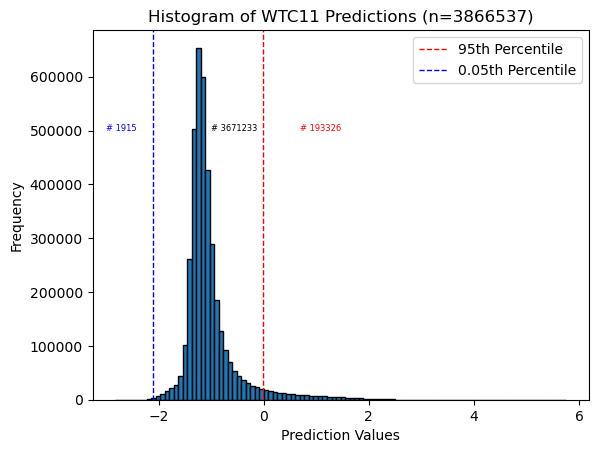

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the 95th percentile and 0.05 percentile
percentile_95 = np.percentile(all_human_screen_230pd_pred_df['prediction'], 95)
percentile_005 = np.percentile(all_human_screen_230pd_pred_df['prediction'], 0.05)

# Calculate the number of sequences lower than the 5th percentile and higher than the 95th percentile
sequences_lower_than_5th = np.sum(all_human_screen_230pd_pred_df['prediction'] < percentile_005)
sequences_higher_than_95th = np.sum(all_human_screen_230pd_pred_df['prediction'] > percentile_95)
sequences_middle = all_human_screen_230pd_pred_df.loc[(all_human_screen_230pd_pred_df['prediction'] < percentile_95) & (all_human_screen_230pd_pred_df['prediction'] > percentile_005)].shape[0]

# Plot the histogram of the predictions
plt.hist(all_human_screen_230pd_pred_df['prediction'], bins=100, edgecolor='black')
plt.axvline(percentile_95, color='r', linestyle='dashed', linewidth=1, label='95th Percentile')
plt.axvline(percentile_005, color='b', linestyle='dashed', linewidth=1, label='0.05th Percentile')
plt.title(f'Histogram of WTC11 Predictions (n={all_human_screen_230pd_pred_df.shape[0]})')
plt.xlabel('Prediction Values')
plt.ylabel('Frequency')
plt.legend()

# Add text annotations for the number of sequences lower than the 5th percentile and higher than the 95th percentile
plt.text(-3, 500000, f'# {sequences_lower_than_5th}', color='blue', fontsize=6)
plt.text(0.7, 500000, f'# {sequences_higher_than_95th}', color='red', fontsize=6)
plt.text(-1, 500000, f'# {sequences_middle}', color='black', fontsize=6)
plt.show()

In [ ]:
# load the cCREs fasta file and get the sequence information
cCREs_fasta_name = config["files"]["cCREs_human_SCREEN_200bp_fasta_centered_name"]
cCREs_human_fasta_path = "/".join(config["files"]["cCREs_human_SCREEN_bed"].split("/")[:-1])
all_human_screen_fasta_df = hf.fasta_to_dataframe(os.path.join(cCREs_human_fasta_path, cCREs_fasta_name))

NameError: name 'config' is not defined

### Collecting elements for ism variant prediction
- Max: 15-20000 elements with more high and less low as well as random (70, 15, 15) split
1. Collect 14k high, 3k low and 3k random elements


In [ ]:
import matplotlib.pyplot as plt

(array([ 1.,  0.,  0.,  0.,  2.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,
         0.,  1.,  0.,  1.,  0.,  2.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  3.,  0.,  2.,  0.,  1.,  2.,  0.,  2.,  1.,
         3.,  0.,  0.,  1.,  1.,  3.,  1.,  3.,  2.,  2.,  1.,  1.,  2.,
         2.,  2.,  3.,  3.,  2.,  1.,  1.,  2.,  2.,  0.,  1.,  6.,  3.,
         1.,  3.,  2.,  3.,  4.,  2.,  2.,  3.,  5.,  5.,  1., 14.,  8.,
        12.,  6.,  5.,  9.,  9.,  9., 17.,  9., 26., 11., 24., 30., 33.,
        27., 24., 35., 34., 39., 40., 39., 32., 52., 51., 49., 53., 54.,
        58., 61., 35., 59., 52., 49., 59., 56., 59., 48., 52., 58., 57.,
        60., 65., 46., 45., 48., 50., 33., 48., 32., 36., 34., 47., 34.,
        26., 24., 16., 30., 19., 22., 25., 26., 10., 16.,  8., 19., 12.,
        14., 15., 13., 13., 15., 16.,  9.,  7.,  9., 13.,  9., 12.,  8.,
         6.,  9.,  3., 17.,  6.,  7.,  4.,  7., 13.,  2.,  6.,  9.,  6.,
         4.,  8.,  8.,  3.,  7.,  5., 12.,  6.,  6.

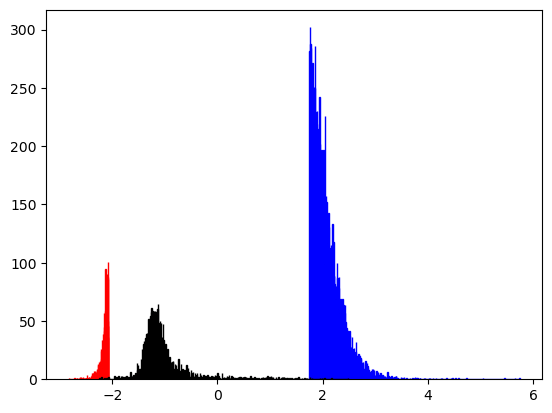

In [ ]:
# high: get the 14000 highest scoring sequences
high_sequences = all_human_screen_230pd_pred_df.sort_values(by="seq_prediction", ascending=False).head(14000)
high_sequences['seq_prediction_class'] = 'high'
# low: get the 3K lowest scoring sequences
low_sequences = all_human_screen_230pd_pred_df.sort_values(by="seq_prediction", ascending=True).head(3000)
low_sequences['seq_prediction_class'] = 'low'

# random: get 3k random sequences from the whole data set
random_sequences = all_human_screen_230pd_pred_df.sample(n=3000, random_state=777)
random_sequences['seq_prediction_class'] = 'random'



# visualize the prediction distribution of the low sequences
plt.hist(low_sequences["seq_prediction"], bins=500, edgecolor='red')

# visualize the prediction distribution of the high sequences
plt.hist(high_sequences["seq_prediction"], bins=500, edgecolor='blue')

# visualize the prediction distribution of the random sequences
plt.hist(random_sequences["seq_prediction"], bins=500, edgecolor='black')

In [ ]:
# combine the dataframes and check for duplicates
combined_sequences = pd.concat([high_sequences, low_sequences, random_sequences])
print(combined_sequences.shape[0])

20000


In [ ]:
# duplicates
duplicates = combined_sequences[combined_sequences.duplicated(subset="sequence", keep=False)].sort_values(by="sequence")
duplicates # 15 duplicates

# resolve the duplicates by combineing the seq_prediction_class of two duplicates
duplicates["seq_prediction_class"] = duplicates.groupby("sequence")["seq_prediction_class"].transform(lambda x: ",".join(x.sort_values().unique()))
duplicates = duplicates.drop_duplicates(subset="sequence", keep="first")
duplicates.head()

,header,sequence,old_header,seq_prediction,chr,start,end,REF_ID,seq_prediction_class
1313550,chr17:1048617-1048847,AGCTGCGCCTGGATCACGTCCGGGGCCACGGTCAAGAAGCTCGGCG...,EH38D4978818::chr17:1048617-1048847,-2.213,chr17,1048617,1048847,NA,"low,random"
3099195,chr7:45704025-45704255,AGGGCTGGGCAGCCTCATCTACAGATGGGCAGGCAGGTGGGTGCCT...,EH38D5851624_1::chr7:45704025-45704255,-2.252,chr7,45704025,45704255,NA,"low,random"
2360117,chr3:162512484-162512714,ATAAAAAGCCAGAATAAAAGTCACAAATACCAAGATTTGGAAGCAA...,EH38D3509900_1::chr3:162512484-162512714,1.762,chr3,162512484,162512714,NA,"high,random"
2689862,chr5:80917185-80917415,ATTTCACTTCTGCCAAAAATGTTATTTTGATACTTGGTGTCCCTTT...,EH38D5661779::chr5:80917185-80917415,1.984,chr5,80917185,80917415,NA,"high,random"
321481,chr10:670088-670318,CATACACACACATCCACACGTGTACATATGCTCATACATGTACACG...,EH38D4483840::chr10:670088-670318,-2.207,chr10,670088,670318,NA,"low,random"


In [ ]:
# remove duplicates and combine the dataframes
combined_sequences = pd.concat([combined_sequences[~combined_sequences.duplicated(subset="sequence", keep=False)], duplicates])

In [ ]:
output_path = os.path.join(os.path.dirname(config["files"]["cCREs_human_SCREEN_bed"]), config['files']['cCREs_human_SCREEN_230bp_chosen_regions'])
combined_sequences.to_csv(output_path, sep="\t", index=False)

# write fasta
output_fasta = os.path.join(os.path.dirname(config["files"]["cCREs_human_SCREEN_bed"]), config['files']['cCREs_human_SCREEN_230bp_chosen_regions_fasta'])
hf.write_fasta(combined_sequences, output_fasta)

In [ ]:
# # write out the elements above 0.5
# element_prediction_df[element_prediction_df['prediction'] > 0.5].to_csv("elements_above_0.5.tsv", sep="\t", index=False, header=False)

In [ ]:
# load all 200bp
import pandas as pd
all_200bp_regions = "/home/kisa11/work/projects/NGN2_design/2025_IGVF_design_WTC11_neural_progenitors/resources/cCREs_all_human_SCREEN/cCREs_all_human_SCREEN_200bp_chosen_regions.tsv.gz"
all_200bp_regions_df = pd.read_csv(all_200bp_regions, sep="\t")

In [ ]:
all_200bp_regions_df

,ID,seq_prediction,chr,start,end,Ref_ID,sequence,seq_prediction_class
0,EH38D2490191::chr11:102667941-102668141,6.083144,chr11,102667941,102668141,NaN,AGGACCGGATCAACTATATATATGCATATGTACTTGCATATGTATA...,high
1,EH38D3870941::chr6:88929881-88930081,5.021067,chr6,88929881,88930081,NaN,AGGACCGGATCAACTACACATATATACATATGTATACATATGCATA...,high
2,EH38D5356028::chr21:13506765-13506965,4.493833,chr21,13506765,13506965,NaN,AGGACCGGATCAACTGTATATTATATACATATCATATACATATGTA...,high
3,EH38D3695267::chr5:38820719-38820919,4.336333,chr5,38820719,38820919,NaN,AGGACCGGATCAACTACATATGTATACCTATGCATATATGAATATA...,high
4,EH38F0032914::chr3:128544281-128544481,4.093044,chr3,128544281,128544481,NaN,AGGACCGGATCAACTTCCATATATAATATGCATATTCATATATAAT...,high
...,...,...,...,...,...,...,...,...
19971,EH38F0027757::chr2:235301768-235301968,1.434403,chr2,235301768,235301968,NaN,AGGACCGGATCAACTTCGTTATCCTTCCTCCCACCTCCTCCCCTCC...,"high,random"
19972,EH38D5218655::chr2:102250614-102250814,-2.050822,chr2,102250614,102250814,NaN,AGGACCGGATCAACTTGCCAAATGCAGAGGCTGGCGCGGCTGGCTG...,"low,random"
19973,EH38D6217321::chr12:110957765-110957965,1.369583,chr12,110957765,110957965,NaN,AGGACCGGATCAACTTGCTCTGGGGAACAGTGCCCGTCCCTCCCCA...,"high,random"
19974,EH38D5622673::chr5:193355-193555,-2.039867,chr5,193355,193555,NaN,AGGACCGGATCAACTTGGTAGGTACTGGGGAAGCACCTAGAGGTGG...,"low,random"
